Cost at optimal w : 130261.46873494198
b,w found by gradient descent: 290.00,[ 38.05161505  41.54327451 -30.98894656  36.34177447] 
[460. 232. 178.]


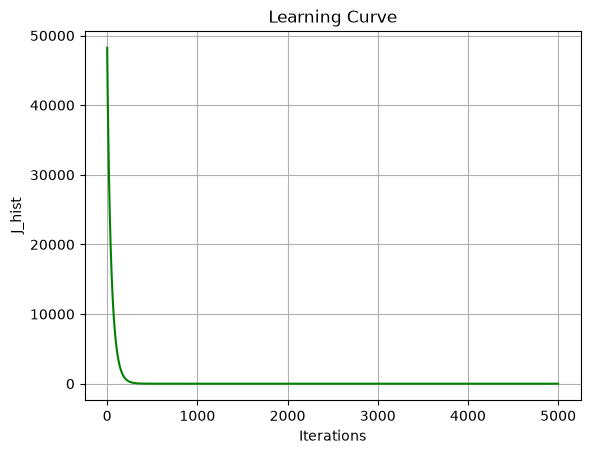

 predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = $330.4879052466946


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import sigma

x_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

#initialising weights and bias
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

#defining the hypothesis
def model(x, w, b):
    return np.dot(x, w) + b

#z-score normalisation
def z_score_norm(x):
    mu = np.mean(x, axis = 0)
    s = np.std(x, axis = 0)
    x_norm = (x - mu)/s
    return x_norm, mu, s

x_train = z_score_norm(x_train)[0]

#defining cost function
def compute_cost(x, y, w, b):
    cost = 0.0
    for i in range(len(x)):
        h = model(x[i], w, b)
        cost += (h - y[i])**2
    return (1/(2*len(x))) * cost

cost = compute_cost(x_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

#defining a function to calculate derivatives
def compute_gradient(x, y, w, b):

    m,n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        e = model(x[i], w, b) - y[i]
        for j in range(n):
            dj_dw[j] += e * x[i,j]
        dj_db += e

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

#performing gradient descent
def gradient_descent(x, y, w_in, b_in, alpha, iters, cost_function, gradient_function):
    J = []
    w = w_in.copy()
    b = b_in
    #r = np.ones((w.shape))
    num_iters = []

    for i in range(iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J.append(cost_function(x, y, w, b))
        num_iters.append(i)
    return w, b, J, num_iters

#testing implementation
initial_w = np.zeros_like(w_init)
initial_b = 0.
iters = 5000
alpha = 0.01
w_final, b_final, J_hist, iterations = gradient_descent(x_train, y_train, initial_w, initial_b, alpha, iters, compute_cost, compute_gradient)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")

print(model(x_train, w_final, b_final))

plt.plot(iterations,J_hist, color = 'green')
plt.title("Learning Curve")
plt.grid()
plt.xlabel("Iterations")
plt.ylabel("J_hist")
plt.show()

#predicting the price of a new house
x_house = np.array([1200, 3, 1, 40])
x_norm = z_score_norm(x_house)[0]
x_predict = model(x_norm, w_final, b_final)
print(f" predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = ${x_predict}")

